In [1]:
# Install necessary packages
!pip install python-binance pandas numpy plotly nbformat ipykernel scikit-learn seaborn matplotlib tensorflow

import pandas as pd
import numpy as np
from binance.client import Client
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

DEPRECATION: Loading egg at /Users/jcamilovasquezm/visualStudioProjects/TWS_IBKR_Trading/venv/lib/python3.11/site-packages/ibapi-10.34.2-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# In your notebook cell
from app_df import PTLClient, get_historical_dataframe, DEFAULT_HOST, PAPER_TRADING_PORT, DEFAULT_CLIENT_ID

# Create an instance of your client
client = PTLClient(DEFAULT_HOST, PAPER_TRADING_PORT, DEFAULT_CLIENT_ID)

# Now request historical data (for example, EUR USD data) and get it as a DataFrame.
# Adjust the parameters as needed (symbol, timeframe, etc.)
df = get_historical_dataframe(client, "EUR", "4 hours", "20250220 00:00:00 US/Eastern", "1 Y")

print(df.head())

ERROR -1 1740695997145 2104 Market data farm connection is OK:usfarm.nj
ERROR -1 1740695997147 2104 Market data farm connection is OK:usfarm
ERROR -1 1740695997147 2106 HMDS data farm connection is OK:ushmds
ERROR -1 1740695997147 2158 Sec-def data farm connection is OK:secdefil


next valid id is 1
getting bar data for EUR 4 hours


ERROR -1 1740696001166 2106 HMDS data farm connection is OK:cashhmds


end of data 20240220 00:00:00 US/Eastern 20250220 00:00:00 US/Eastern
                              Open     High      Low    Close  Volume
Datetime                                                             
2024-02-21 22:15:00+00:00  1.08175  1.08226  1.08175  1.08201      -1
2024-02-22 00:00:00+00:00  1.08201  1.08321  1.08190  1.08258      -1
2024-02-22 04:00:00+00:00  1.08258  1.08539  1.08253  1.08531      -1
2024-02-22 08:00:00+00:00  1.08531  1.08882  1.08448  1.08574      -1
2024-02-22 12:00:00+00:00  1.08574  1.08586  1.08027  1.08102      -1


In [3]:
df.head()

,Open,High,Low,Close,Volume
Datetime,,,,,
2024-02-21 22:15:00+00:00,1.08175,1.08226,1.08175,1.08201,-1
2024-02-22 00:00:00+00:00,1.08201,1.08321,1.08190,1.08258,-1
2024-02-22 04:00:00+00:00,1.08258,1.08539,1.08253,1.08531,-1
2024-02-22 08:00:00+00:00,1.08531,1.08882,1.08448,1.08574,-1
2024-02-22 12:00:00+00:00,1.08574,1.08586,1.08027,1.08102,-1


In [4]:
df.shape

(1807, 5)

In [5]:
# -------------------------------
# Add Technical Indicators
# -------------------------------
def add_ema(df, periods=[20, 50, 100, 200]):
    for period in periods:
        df[f'EMA_{period}'] = df['Close'].ewm(span=period, adjust=False).mean()
    return df

df = add_ema(df)

In [310]:
df

,Open,High,Low,Close,Volume,EMA_20,EMA_50,EMA_100,EMA_200
Datetime,,,,,,,,,
2024-02-21 22:15:00+00:00,1.08175,1.08226,1.08175,1.08201,-1,1.08201,1.08201,1.08201,1.08201
2024-02-22 00:00:00+00:00,1.08201,1.08321,1.08190,1.08258,-1,1.08206,1.08203,1.08202,1.08202
2024-02-22 04:00:00+00:00,1.08258,1.08539,1.08253,1.08531,-1,1.08237,1.08216,1.08209,1.08205
2024-02-22 08:00:00+00:00,1.08531,1.08882,1.08448,1.08574,-1,1.08269,1.08230,1.08216,1.08209
2024-02-22 12:00:00+00:00,1.08574,1.08586,1.08027,1.08102,-1,1.08253,1.08225,1.08214,1.08207
...,...,...,...,...,...,...,...,...,...
2025-02-19 16:00:00+00:00,1.04241,1.04324,1.04007,1.04258,-1,1.04491,1.04317,1.04107,1.04020
2025-02-19 20:00:00+00:00,1.04258,1.04265,1.04208,1.04223,-1,1.04466,1.04314,1.04109,1.04022
2025-02-19 22:15:00+00:00,1.04199,1.04266,1.04197,1.04207,-1,1.04441,1.04310,1.04111,1.04024


In [6]:
# -------------------------------
# Prepare Data (Feature Engineering)
# -------------------------------
def prepare_data(data, sma_window=14, rsi_window=14):
    # Calculate basic indicators
    data['Returns'] = data['Close'].pct_change()
    data['SMA'] = data['Close'].rolling(window=sma_window).mean()
    data['Std'] = data['Close'].rolling(window=sma_window).std()
    data['Candle_Binary'] = (data['Returns'] > 0).astype(int)
    data['Momentum'] = data['Close'] - data['Close'].shift(5)
    data['Volatility'] = data['Returns'].rolling(window=5).std()
    data['ma5'] = data['Close'].rolling(window=5).mean()
    data['ma10'] = data['Close'].rolling(window=10).mean()
    
    # RSI calculation
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=rsi_window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_window).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    
    # Bar UpDown
    upBar = (data['Close'] > data['Open']) & (data['Open'] > data['Close'].shift(1))
    data['Up_Bar'] = upBar.astype(int)
    downBar = (data['Close'] < data['Open']) & (data['Open'] < data['Close'].shift(1))
    data['Down_Bar'] = downBar.astype(int)
    
    # Create features – you can choose a combination that works best
    features = ['Returns', 'Volatility', 'ma5', 'ma10', 'Momentum', 'Close', 'High', 'Low', 'Open', 'EMA_20', 'EMA_50', 'EMA_100', 'EMA_200', 'SMA', 'Std', 'RSI', 'Up_Bar', 'Down_Bar']
    X = data[features].shift(1)  # Shift by 1 to avoid look-ahead bias
    y = data['Candle_Binary']

    # Pips per candle
    data['Pips'] = data['Returns'] * 10000
    
    # Remove NaN values
    X = X.dropna()
    y = y[X.index]
    
    return X, y

In [7]:
X, y = prepare_data(df, sma_window=14)
df = df.dropna()
df

,Open,High,Low,Close,Volume,EMA_20,EMA_50,EMA_100,EMA_200,Returns,...,Std,Candle_Binary,Momentum,Volatility,ma5,ma10,RSI,Up_Bar,Down_Bar,Pips
Datetime,,,,,,,,,,,,,,,,,,,,,
2024-02-23 20:00:00+00:00,1.08229,1.08245,1.08168,1.08168,-1,1.082408,1.082280,1.082172,1.082099,-0.000564,...,0.001286,0,-0.00085,0.000444,1.082336,1.082227,48.637490,0,0,-5.636197
2024-02-25 22:15:00+00:00,1.08150,1.08245,1.08150,1.08190,-1,1.082359,1.082265,1.082167,1.082097,0.000203,...,0.001291,1,-0.00104,0.000395,1.082128,1.082315,49.553933,0,0,2.033873
2024-02-26 00:00:00+00:00,1.08190,1.08202,1.08126,1.08185,-1,1.082311,1.082249,1.082160,1.082095,-0.000046,...,0.001311,0,-0.00086,0.000400,1.081956,1.082276,46.909399,0,0,-0.462150
2024-02-26 04:00:00+00:00,1.08185,1.08367,1.08174,1.08320,-1,1.082396,1.082286,1.082181,1.082106,0.001248,...,0.001083,1,0.00114,0.000660,1.082184,1.082370,39.884947,0,0,12.478625
2024-02-26 08:00:00+00:00,1.08320,1.08540,1.08270,1.08519,-1,1.082662,1.082400,1.082241,1.082136,0.001837,...,0.000959,1,0.00290,0.000982,1.082764,1.082635,47.706422,0,0,18.371492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-19 16:00:00+00:00,1.04241,1.04324,1.04007,1.04258,-1,1.044912,1.043175,1.041069,1.040201,0.000163,...,0.001959,1,-0.00223,0.001193,1.043540,1.044451,17.824074,0,0,1.630836
2025-02-19 20:00:00+00:00,1.04258,1.04265,1.04208,1.04223,-1,1.044657,1.043138,1.041092,1.040221,-0.000336,...,0.001898,0,-0.00290,0.001127,1.042960,1.044046,14.662085,0,0,-3.357057
2025-02-19 22:15:00+00:00,1.04199,1.04266,1.04197,1.04207,-1,1.044410,1.043096,1.041111,1.040239,-0.000154,...,0.001718,0,-0.00305,0.001111,1.042350,1.043590,13.522727,0,0,-1.535170


In [9]:
# -------------------------------
# Create Sequences for LSTM
# -------------------------------
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(window_size, len(X)):
        Xs.append(X.iloc[i-window_size:i].values)
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

# Choose a sequence length (e.g., 10 time steps)
window_size = 10
X_seq, y_seq = create_sequences(X, y, window_size)
print("LSTM Input Shape:", X_seq.shape)  # (samples, timesteps, features)

LSTM Input Shape: (1783, 10, 18)


In [10]:
# -------------------------------
# Train-Test Split (Chronological)
# -------------------------------
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

In [11]:
from app_df import PTLClient, get_historical_dataframe, DEFAULT_HOST, PAPER_TRADING_PORT, DEFAULT_CLIENT_ID
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dropout, LSTM, Bidirectional, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -------------------------------
# Build the LSTM Model
# -------------------------------
num_features = X_train.shape[2]
input_shape = (X_seq.shape[1], X_seq.shape[2])
model = Sequential()
# 1D Convolution layer to capture local patterns across candles
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Bidirectional LSTM layer to capture sequential dependencies (using only past data)
model.add(Bidirectional(LSTM(units=64, return_sequences=True, recurrent_dropout=0.2)))
model.add(Dropout(0.2))

# Additional LSTM layer (unidirectional) to summarize the sequence
model.add(LSTM(units=64, recurrent_dropout=0.2))
model.add(Dropout(0.2))

# Optional Dense layer to learn non-linear combinations of features
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output layer: Predict probability of a bullish (long) move
model.add(Dense(1, activation='sigmoid'))

# Compile with a slightly lower learning rate for fine-grained updates
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])
model.summary()




/Users/jcamilovasquezm/visualStudioProjects/TWS_IBKR_Trading/venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 8, 128)         │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,073 (402.63 KB)

 Trainable params: 103,009 (402.38 KB)

 Non-trainable params: 64 (256.00 B)

In [12]:
# -------------------------------
# Train the LSTM Model
# -------------------------------
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                    validation_split=0.1, verbose=1)
                    

# -------------------------------
# 6. Evaluate the LSTM Model
# -------------------------------
# Predict probabilities and round to 0/1
from sklearn.metrics import roc_curve

# Get predicted probabilities for the positive class
y_pred_prob = model.predict(X_test).flatten()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute Youden's J statistic: J = tpr - fpr
j_scores = tpr - fpr
optimal_idx = j_scores.argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.2f}")

# Now use this threshold to get final binary predictions:
y_pred = (y_pred_prob >= optimal_threshold).astype(int)



Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.4708 - loss: 0.6974 - val_accuracy: 0.4965 - val_loss: 0.7179
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5098 - loss: 0.6937 - val_accuracy: 0.4755 - val_loss: 0.7088
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5106 - loss: 0.6979 - val_accuracy: 0.5035 - val_loss: 0.7033
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5503 - loss: 0.6902 - val_accuracy: 0.5035 - val_loss: 0.6978
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5297 - loss: 0.6920 - val_accuracy: 0.5105 - val_loss: 0.6992
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5188 - loss: 0.6881 - val_accuracy: 0.4965 - val_loss: 0.6964
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5740 - loss: 0.6833 - val_accuracy: 0.5315 - val_loss: 0.6970
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5604 - loss: 0.6817 - val_accuracy: 0.5315 - va

In [13]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")
print("\nMean Squared Error Report:")
print(mse)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Test Accuracy: 0.52

Mean Squared Error Report:
0.47619047619047616

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.51      0.51       176
           1       0.53      0.54      0.54       181

    accuracy                           0.52       357
   macro avg       0.52      0.52      0.52       357
weighted avg       0.52      0.52      0.52       357


Confusion Matrix:
[[89 87]
 [83 98]]


# Model in Action

In [227]:
# In your notebook cell
from app_df import PTLClient, get_historical_dataframe, DEFAULT_HOST, PAPER_TRADING_PORT, DEFAULT_CLIENT_ID

# Create an instance of your client
client = PTLClient(DEFAULT_HOST, PAPER_TRADING_PORT, DEFAULT_CLIENT_ID)

# Now request historical data (for example, EUR USD data) and get it as a DataFrame.
# Adjust the parameters as needed (symbol, timeframe, etc.)
df_test = get_historical_dataframe(client, "EUR", "4 hours", "20241230 00:00:00 US/Eastern", "1 Y")

print(df_test.head())

ERROR -1 1740536345270 2104 Market data farm connection is OK:usfarm.nj
ERROR -1 1740536345271 2104 Market data farm connection is OK:usfarm
ERROR -1 1740536345271 2106 HMDS data farm connection is OK:cashhmds
ERROR -1 1740536345271 2106 HMDS data farm connection is OK:ushmds
ERROR -1 1740536345273 2158 Sec-def data farm connection is OK:secdefil


next valid id is 1
getting bar data for EUR 4 hours
end of data 20231230 00:00:00 US/Eastern 20241230 00:00:00 US/Eastern
                             Open    High     Low   Close  Volume
Datetime                                                         
2024-01-02 00:00:00+00:00 1.10365 1.10432 1.10177 1.10245      -1
2024-01-02 04:00:00+00:00 1.10245 1.10380 1.10151 1.10153      -1
2024-01-02 08:00:00+00:00 1.10153 1.10388 1.09666 1.09692      -1
2024-01-02 12:00:00+00:00 1.09692 1.09718 1.09409 1.09435      -1
2024-01-02 16:00:00+00:00 1.09435 1.09616 1.09408 1.09464      -1


In [228]:
df_test.shape

(1807, 5)

In [229]:
# Bar UpDown

def is_bullish_bar(prev, curr):
    """
    Bullish Bar:
        - Previous candle is bearish (Close < Open)
        - Current candle is bullish (Close > Open)
        """
    if (prev['Close'] < prev['Open']) and (curr['Close'] > curr['Open']):
        return True


def is_bearish_bar(prev, curr):
    """
    Bearish Bar:
        - Previous candle is bullish (Close > Open)
        - Current candle is bearish (Close < Open)
        """
    if (prev['Close'] > prev['Open']) and (curr['Close'] < curr['Open']):
        return True

In [230]:
df_test = add_ema(df_test)

In [231]:
# Filter the data to only include the best hours

df_copy = df_test.copy()

# best_hours = [3, 7, 11, 19]
# df_test = df_test[df_test.index.hour.isin(best_hours)]

# Extract the hour from the index and store it in a new column
df_test['hour'] = df_test.index.hour

df_test.head(12)

,Open,High,Low,Close,Volume,EMA_20,EMA_50,EMA_100,EMA_200,hour
Datetime,,,,,,,,,,
2024-01-02 00:00:00+00:00,1.10365,1.10432,1.10177,1.10245,-1,1.10245,1.10245,1.10245,1.10245,0
2024-01-02 04:00:00+00:00,1.10245,1.10380,1.10151,1.10153,-1,1.10236,1.10241,1.10243,1.10244,4
2024-01-02 08:00:00+00:00,1.10153,1.10388,1.09666,1.09692,-1,1.10184,1.10220,1.10232,1.10239,8
2024-01-02 12:00:00+00:00,1.09692,1.09718,1.09409,1.09435,-1,1.10113,1.10189,1.10216,1.10231,12
2024-01-02 16:00:00+00:00,1.09435,1.09616,1.09408,1.09464,-1,1.10051,1.10161,1.10202,1.10223,16
2024-01-02 20:00:00+00:00,1.09464,1.09511,1.09382,1.09405,-1,1.09990,1.10131,1.10186,1.10215,20
2024-01-02 22:15:00+00:00,1.09400,1.09445,1.09396,1.09414,-1,1.09935,1.10103,1.10171,1.10207,22
2024-01-03 00:00:00+00:00,1.09414,1.09622,1.09412,1.09607,-1,1.09904,1.10083,1.10159,1.10201,0
2024-01-03 04:00:00+00:00,1.09607,1.09628,1.09512,1.09604,-1,1.09875,1.10065,1.10148,1.10195,4


In [232]:
X_sim, y_sim = prepare_data(df_test, sma_window=14)

# Choose a sequence length (e.g., 10 time steps)
window_size = 10
X_seq_sim, y_seq_sim = create_sequences(X_sim, y_sim, window_size)
print("LSTM Input Shape:", X_seq_sim.shape)  # (samples, timesteps, features)

LSTM Input Shape: (1783, 10, 4)


In [233]:
capital = 10000.0  # starting capital in USD
trades = []
l_trades_quantity = 0
s_trades_quantity = 0
l_profit = 0.0
s_profit = 0.0
# Micro lot size: 1 pip = $0.10  (trade volume = 0.1)
# Mini lot size: 1 pip = $1.00 (trade volume = 1)
# Standard lot size: 1 pip = $10.00 (trade volume = 10)
trade_volume = 10
spread = 1
min_accuracy = 0.5

# Define best hours for trading (for 4h timeframe in this example)
best_hours_4h = [4, 11]
best_hours_1h = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
all_hours = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

def calculate_profit(pips): 
    return ((pips - spread) * trade_volume)

# For simulation, we assume that each sequence's prediction corresponds to trading on the next candle.
# Because our sequences are created from X_sim (with indices aligned to df_sim),
# the candle to trade is the one at index: X_sim.index[window_size + i].
sim_indices = X_sim.index[window_size:]

for i in range(len(X_seq_sim)):
    # Get prediction from LSTM model for the current sequence
    seq = X_seq_sim[i:i+1]  # shape (1, window_size, features)
    pred_prob = model.predict(seq)[0, 0]
    # predicted_signal = int(np.round(pred_prob))  # 1 for bullish, 0 for bearish
    model_signal = (pred_prob > optimal_threshold).astype(int).flatten()[0]
    
    # Identify the corresponding candle for trading from the simulation DataFrame
    candle_idx = sim_indices[i]
    idx = df_test.index.get_loc(candle_idx)
    today = df_test.iloc[idx]
    yesterday = df_test.iloc[idx - 1]
    day_before_yesterday = df_test.iloc[idx - 2]
    
    pattern_signal = 2

    # Bar UpDown
    if is_bullish_bar(day_before_yesterday, yesterday):
        pattern_signal = 1
    elif is_bearish_bar(day_before_yesterday, yesterday):
        pattern_signal = 0

    # Engulfing
    # if is_bullish_engulfing(day_before_yesterday, yesterday):
    #     pattern_signal = 1
    # elif is_bearish_engulfing(day_before_yesterday, yesterday):
    #     pattern_signal = 0
    
    # Final signal: pattern confirmation takes precedence if available.
    signal = 2
    # signal = pattern_signal if pattern_signal is not 2 else model_signal
    signal = model_signal

    # Final signal Matching both predicted and pattern:
    # if (pattern_signal == model_signal):
    #     signal = pattern_signal
    
    profit = 0.0  # Initialize profit to 0.0 if no trade is made.
    # Simulate trade: enter at the Open and exit at the Close of the day.

    if today['hour'] in all_hours:
        if signal == 1:
            pseudo_pips = today['Close'] - today['Open']
            pips = (pseudo_pips * 10000) 
            profit = calculate_profit(pips)
            l_trades_quantity += 1
            l_profit += profit

        if signal == 0:
            pseudo_pips = today['Open'] - today['Close']
            pips = (pseudo_pips * 10000)
            profit = calculate_profit(pips)
            s_trades_quantity += 1
            s_profit += profit

        
        capital += profit  # Update capital (note: this is a simplified model, not accounting for leverage or trade sizing)
        trades.append({
            'date': today.name,
            'ms': model_signal,
            'ps': pattern_signal,
            's': signal,
            'Open': today['Open'],
            'Close': today['Close'],
            'profit': profit,
            'capital': capital
        })

print("\nTrading Simulation Results:")
print(f"\nLong Trades Quantity: {l_trades_quantity}, Short Trades Quantity: {s_trades_quantity}")
print(f"\nLong Profit: {l_profit:.2f}, Short Profit: {s_profit:.2f}")
print("\nFinal Capital: $", round(capital, 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

In [234]:
# Convert simulation results to a DataFrame and display
trades_df = pd.DataFrame(trades)
print("\nTrading Simulation Results (first 30 rows):")
print(trades_df.head(30))
print(f"\nTotal Long Trades: {l_trades_quantity}, Total Short Trades: {s_trades_quantity}")
print("\nFinal Capital: $", round(capital, 2))


Trading Simulation Results (first 30 rows):
                        date  ms  ps  s    Open   Close     profit     capital
0  2024-01-05 12:00:00+00:00   1   2  1 1.09140 1.09782  632.00000 10632.00000
1  2024-01-05 16:00:00+00:00   1   1  1 1.09782 1.09452 -340.00000 10292.00000
2  2024-01-05 20:00:00+00:00   1   0  1 1.09452 1.09403  -59.00000 10233.00000
3  2024-01-07 22:15:00+00:00   1   2  1 1.09400 1.09414    4.00000 10237.00000
4  2024-01-08 00:00:00+00:00   1   1  1 1.09414 1.09329  -95.00000 10142.00000
5  2024-01-08 04:00:00+00:00   1   0  1 1.09329 1.09453  114.00000 10256.00000
6  2024-01-08 08:00:00+00:00   1   1  1 1.09453 1.09378  -85.00000 10171.00000
7  2024-01-08 12:00:00+00:00   1   0  1 1.09378 1.09695  307.00000 10478.00000
8  2024-01-08 16:00:00+00:00   1   1  1 1.09695 1.09610  -95.00000 10383.00000
9  2024-01-08 20:00:00+00:00   1   0  1 1.09610 1.09499 -121.00000 10262.00000
10 2024-01-08 22:15:00+00:00   1   2  1 1.09490 1.09496   -4.00000 10258.00000
11 2024

In [235]:
# Calculate additional metrics

# 1. Cumulative Maximum Capital: running max of the 'capital' column
trades_df['cum_max'] = trades_df['capital'].cummax()

# 2. Drawdown (in dollars) = current capital minus running maximum capital
trades_df['drawdown'] = trades_df['capital'] - trades_df['cum_max']

# 3. Drawdown Percentage
trades_df['drawdown_pct'] = (trades_df['drawdown'] / trades_df['cum_max']) * 100

# 4. Profit Factor:
# Sum up profits from winning trades and absolute losses from losing trades.
total_profit = trades_df.loc[trades_df['profit'] > 0, 'profit'].sum()
total_loss = abs(trades_df.loc[trades_df['profit'] < 0, 'profit'].sum())
profit_factor = total_profit / total_loss if total_loss != 0 else float('inf')

# Print calculated metrics
print("Total Profit: ${:.2f}".format(total_profit))
print("Total Loss: ${:.2f}".format(total_loss))
print("Profit Factor: {:.2f}".format(profit_factor))
print("Maximum Drawdown: ${:.2f}".format(abs(trades_df['drawdown'].min())))
print("Maximum Drawdown (%): {:.2f}%".format(abs(trades_df['drawdown_pct'].min())))



Total Profit: $75390.00
Total Loss: $93442.00
Profit Factor: 0.81
Maximum Drawdown: $18828.00
Maximum Drawdown (%): 177.09%


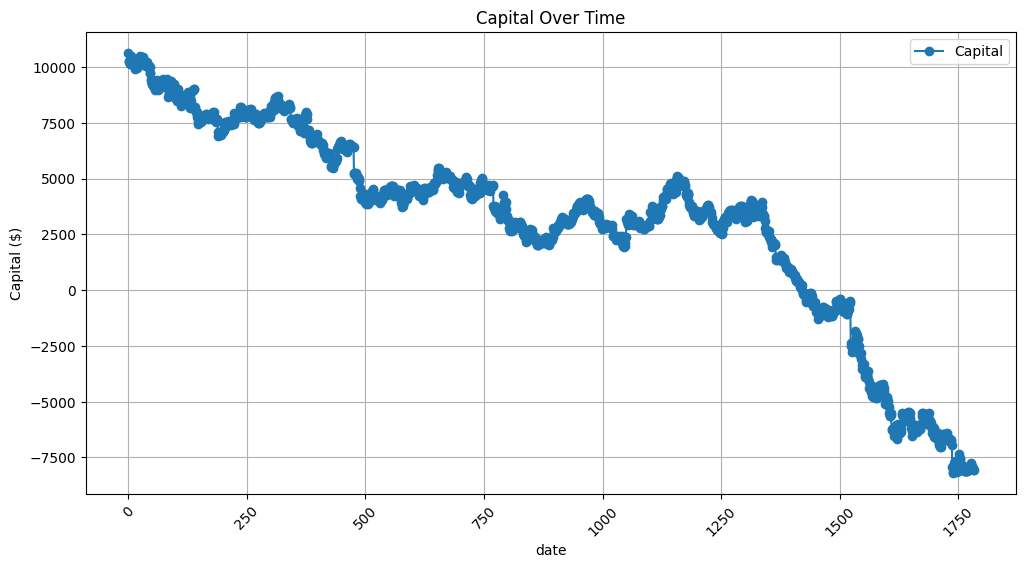

In [236]:
# Plotting the Capital Over Time
plt.figure(figsize=(12, 6))
plt.plot(trades_df.index, trades_df['capital'], marker='o', linestyle='-', label='Capital')
plt.title('Capital Over Time')
plt.xlabel('date')
plt.ylabel('Capital ($)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

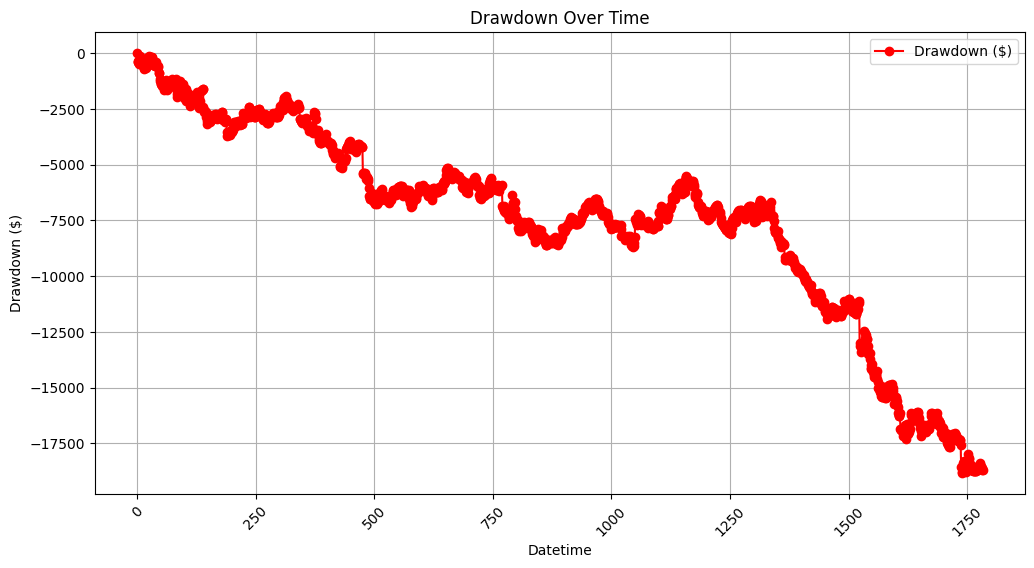

In [237]:
# Plotting the Drawdown Over Time
plt.figure(figsize=(12, 6))
plt.plot(trades_df.index, trades_df['drawdown'], marker='o', linestyle='-', color='red', label='Drawdown ($)')
plt.title('Drawdown Over Time')
plt.xlabel('Datetime')
plt.ylabel('Drawdown ($)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [238]:
# Ensure the 'date' column is a datetime type and set it as the index

# Extract the hour from the index and store it in a new column
trades_df['hour'] = trades_df['date'].dt.hour

# Group by hour and calculate the total profit and average profit per trade for each hour
hourly_profit = trades_df.groupby('hour')['profit'].agg(['sum', 'mean', 'count']).rename(columns={'sum': 'total_profit', 'mean': 'avg_profit', 'count': 'num_trades'})

print(hourly_profit)

      total_profit  avg_profit  num_trades
hour                                      
0      -4865.00000   -19.07843         255
4      -5016.00000   -19.67059         255
8      -2107.00000    -8.29528         254
12     -7105.00000   -27.86275         255
16      -659.00000    -2.58431         255
20     -4094.00000   -16.05490         255
21      3691.00000    21.71176         170
22      2103.00000    25.03571          84


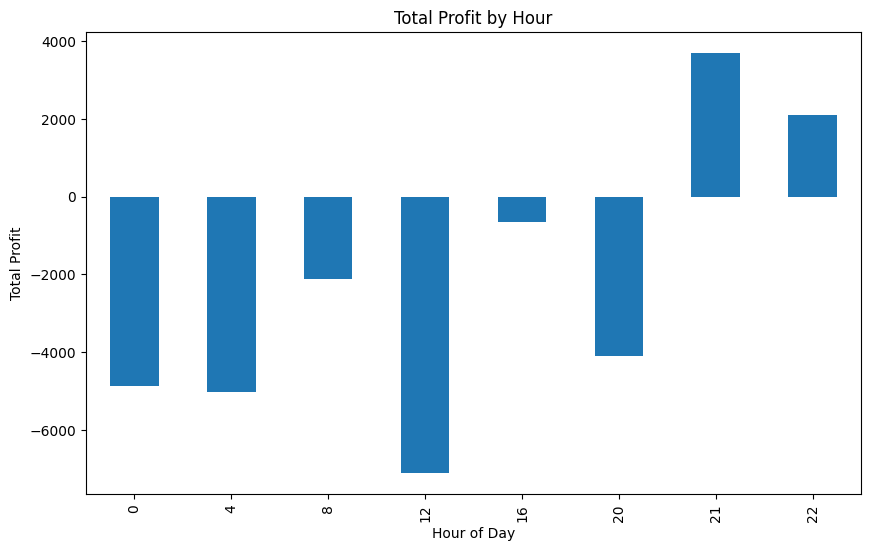

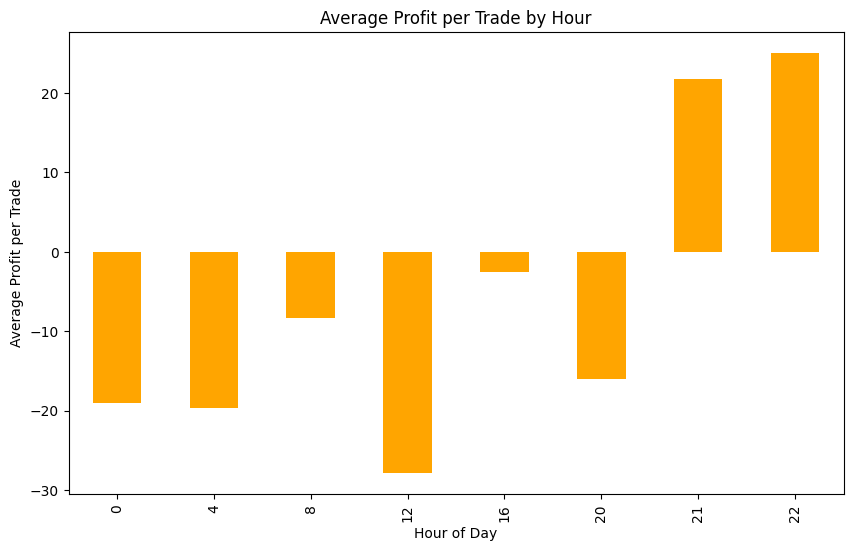

In [239]:
# Plot total profit by hour
hourly_profit['total_profit'].plot(kind='bar', figsize=(10, 6), title='Total Profit by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Profit')
plt.show()

# Plot average profit per trade by hour
hourly_profit['avg_profit'].plot(kind='bar', figsize=(10, 6), color='orange', title='Average Profit per Trade by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Profit per Trade')
plt.show()

# Model with re training

In [56]:
# In your notebook cell
from app_df import PTLClient, get_historical_dataframe, DEFAULT_HOST, PAPER_TRADING_PORT, DEFAULT_CLIENT_ID
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dropout, LSTM, Bidirectional, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create an instance of your client
client = PTLClient(DEFAULT_HOST, PAPER_TRADING_PORT, DEFAULT_CLIENT_ID)

# Request historical data for EUR/USD (adjust parameters as needed)
df_test = get_historical_dataframe(client, "EUR", "4 hours", "20250221 00:00:00 US/Eastern", "3 Y")
print(df_test.head())

ERROR -1 1740699613880 2104 Market data farm connection is OK:usfarm.nj
ERROR -1 1740699613880 2104 Market data farm connection is OK:usfarm
ERROR -1 1740699613880 2106 HMDS data farm connection is OK:cashhmds
ERROR -1 1740699613881 2106 HMDS data farm connection is OK:ushmds
ERROR -1 1740699613881 2158 Sec-def data farm connection is OK:secdefil


next valid id is 1
getting bar data for EUR 4 hours
end of data 20220221 00:00:00 US/Eastern 20250221 00:00:00 US/Eastern
                             Open    High     Low   Close  Volume
Datetime                                                         
2022-02-22 22:15:00+00:00 1.13259 1.13313 1.13259 1.13289      -1
2022-02-23 00:00:00+00:00 1.13289 1.13388 1.13200 1.13258      -1
2022-02-23 04:00:00+00:00 1.13258 1.13427 1.13159 1.13398      -1
2022-02-23 08:00:00+00:00 1.13398 1.13589 1.13338 1.13404      -1
2022-02-23 12:00:00+00:00 1.13404 1.13522 1.13206 1.13245      -1


In [57]:
df_test = add_ema(df_test)
df_test.shape

(5435, 9)

In [58]:
# -----------------------------------------------------------------------------
# BAR UP DOWN PATTERN FUNCTIONS
# -----------------------------------------------------------------------------
def is_bullish_bar(prev, curr):
    """Bullish Bar: previous candle bearish, current candle bullish."""
    return (prev['Close'] < prev['Open']) and (curr['Close'] > curr['Open'])

def is_bearish_bar(prev, curr):
    """Bearish Bar: previous candle bullish, current candle bearish."""
    return (prev['Close'] > prev['Open']) and (curr['Close'] < curr['Open'])

In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dropout, Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


def calculate_bet(prediction: float, threshold: float, min_bet: float = 1, max_bet: float = 50):
    """
    Calculates bet amount based on the prediction confidence relative to a threshold.
    
    Args:
        prediction (float): The model's output in range [0, 1].
        threshold (float): The cutoff threshold to decide bet type.
        min_bet (float): The minimum bet amount when confidence is low.
        max_bet (float): The maximum bet amount when confidence is high.
    
    Returns:
        dict: A dictionary with the chosen bet side and the bet amount.
              'side' is 0 if prediction < threshold, 1 otherwise.
              'bet_amount' is scaled between min_bet and max_bet.
    """
    
    # Determine bet side: 0 if prediction is less than threshold, else 1.
    if prediction < threshold:
        side = 0
        # Normalize confidence from 0 (at threshold) to 1 (at 0)
        confidence = (threshold - prediction) / threshold if threshold != 0 else 0.0
    else:
        side = 1
        # Normalize confidence from 0 (at threshold) to 1 (at 1)
        confidence = (prediction - threshold) / (1 - threshold) if threshold != 1 else 0.0
    
    # Ensure confidence is between 0 and 1.
    confidence = max(0.0, min(confidence, 1.0))
    
    # Scale the bet amount based on the confidence.
    bet_amount = min_bet + (max_bet - min_bet) * confidence
    
    return {"side": side, "bet_amount": bet_amount}


def compute_trade_size(pred_prob, base_volume, min_conf=0.05):
    """
    Computes a trade size based on the model's predicted probability.
    The idea is to trade a smaller size when the model is less confident (i.e. when |p-0.5| is low).
    We scale the trade size linearly so that:
      - when |p - 0.5| is 0, trade size is 0,
      - when |p - 0.5| equals 0.5 (i.e. p is 0 or 1), trade size is the full base_volume.
    """
    # Calculate confidence as the absolute deviation from 0.5.
    confidence = abs(pred_prob - 0.5)
    # Normalize confidence (0 to 1 scale)
    norm_conf = confidence / 0.5  # 0 if p=0.5, 1 if p=0 or 1
    # Optionally, enforce a minimum confidence threshold below which you trade very little
    if norm_conf < min_conf:
        norm_conf = min_conf
    return base_volume * norm_conf


# Prepare data
X_sim, y_sim = prepare_data(df_test, sma_window=14)

# Choose a sequence length (window_size)
window_size = 10
X_seq_sim, y_seq_sim = create_sequences(X_sim, y_sim, window_size)
print("LSTM Input Shape:", X_seq_sim.shape)  # (samples, timesteps, features)

# Extract the hour from the DataFrame index for trading rules
df_test['hour'] = df_test.index.hour

# -----------------------------------------------------------------------------
# DEFINE AND COMPILE THE LSTM MODEL
# -----------------------------------------------------------------------------
def build_lstm_model(input_shape):
    model = Sequential()
    # 1D Convolution layer to capture local patterns across candles
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    
    # Bidirectional LSTM layer to capture sequential dependencies (using only past data)
    model.add(Bidirectional(LSTM(units=64, return_sequences=True, recurrent_dropout=0.2)))
    model.add(Dropout(0.2))
    
    # Additional LSTM layer (unidirectional) to summarize the sequence
    model.add(LSTM(units=64, recurrent_dropout=0.2))
    model.add(Dropout(0.2))
    
    # Optional Dense layer to learn non-linear combinations of features
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    
    # Output layer: Predict probability of a bullish (long) move
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile with a slightly lower learning rate for fine-grained updates
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])
    return model

input_shape = (X_seq_sim.shape[1], X_seq_sim.shape[2])
model = build_lstm_model(input_shape)

# Initial training on the first portion of the data
initial_train_size = int(0.5 * len(X_seq_sim))  # Adjust as needed
history = model.fit(X_seq_sim[:initial_train_size], y_seq_sim[:initial_train_size],
                    epochs=20, batch_size=32, verbose=1)

optimal_threshold = 0.5  # threshold for converting probability to a binary signal

# -----------------------------------------------------------------------------
# ENHANCED FUNCTION TO OPTIMIZE THRESHOLD WITH HOLD-OUT VALIDATION AND SMOOTHING
# -----------------------------------------------------------------------------
def optimize_threshold(model, X_data, y_data, thresholds=np.linspace(0.30, 0.70, 20), current_threshold=0.5, smoothing_factor=0.3):
    """
    Optimizes the probability-to-signal threshold using a hold-out validation set.
    
    Steps:
      1. Split the new data into training and validation sets.
      2. Compute predictions on the validation set.
      3. Grid search for the threshold that maximizes accuracy.
      4. Smooth the new threshold with the previous one to avoid abrupt changes.
    
    Parameters:
      - model: the trained model.
      - X_data, y_data: new data collected for threshold optimization.
      - thresholds: candidate threshold values.
      - current_threshold: the threshold currently in use.
      - smoothing_factor: weight given to the new optimal threshold (0 < smoothing_factor <= 1).
    
    Returns:
      - updated_threshold: the new threshold after smoothing.
      - best_acc: the accuracy corresponding to the optimal threshold on validation data.
    """
    # Split new data: 80% remains for model update and 20% for threshold validation.
    _, X_val, _, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    
    pred_probs = model.predict(X_val)
    best_threshold = thresholds[0]
    best_accuracy = 0
    
    for th in thresholds:
        preds = (pred_probs > th).astype(int)
        acc = np.mean(preds.flatten() == y_val)
        if acc > best_accuracy:
            best_accuracy = acc
            best_threshold = th

    # Apply smoothing to avoid abrupt threshold shifts:
    updated_threshold = (1 - smoothing_factor) * current_threshold + smoothing_factor * best_threshold
    return updated_threshold, best_accuracy

# -----------------------------------------------------------------------------
# BACKTESTING & ONLINE RETRAINING SETUP
# -----------------------------------------------------------------------------
capital = 10000.0  # starting capital in USD
trades = []
l_trades_quantity = 0
s_trades_quantity = 0
l_profit = 0.0
s_profit = 0.0

# Trading parameters
trade_volume = 10  # Standard lot size: 1 pip = $10.00 (trade volume = 10)
spread = 1         # spread in pips

# Define trading hours (for this example, we allow all hours)
all_hours = list(range(25))

def calculate_profit(pips, trade_v):
    """Calculate profit given pips moved after adjusting for spread."""
    return ((pips - spread) * trade_v)

# Set retraining frequency (e.g., retrain every 50 candles processed)
update_frequency = 50  
new_X_buffer = []  # buffer to collect new sequences for retraining
new_y_buffer = []  # buffer for corresponding targets

# We'll also maintain rolling accuracy counters for the current model
correct_count = 0
total_count = 0
current_accuracy = 0.0

# For simulation, the trading candle for a given sequence is at:
sim_indices = X_sim.index[window_size:]

# -----------------------------------------------------------------------------
# BACKTESTING LOOP WITH ONLINE RETRAINING AND ACCURACY CHECK
# -----------------------------------------------------------------------------
for i in range(initial_train_size, len(X_seq_sim)-1):  
    seq = X_seq_sim[i:i+1]  # shape (1, window_size, features)
    pred_prob = model.predict(seq)[0, 0]
    model_signal = int(pred_prob > optimal_threshold)

    bet_calculation = calculate_bet(prediction=current_accuracy, threshold=optimal_threshold)
    # model_signal = bet_calculation['side']

    # Instead of filtering trades based on retrospective accuracy, we compute
    # a confidence-based trade size. Lower confidence (i.e. p near 0.5) reduces exposure.
    # trade_size = compute_trade_size(pred_prob, trade_volume)
    trade_size = bet_calculation['bet_amount']

    # Identify the corresponding candle for trading from df_test.
    candle_idx = sim_indices[i]
    idx = df_test.index.get_loc(candle_idx)
    today = df_test.iloc[idx]
    yesterday = df_test.iloc[idx - 1]
    day_before_yesterday = df_test.iloc[idx - 2]
    
    # Compute the pattern signal using Bar UpDown strategy.
    pattern_signal = 2  # default (no signal)
    if is_bullish_bar(day_before_yesterday, yesterday):
        pattern_signal = 1
    elif is_bearish_bar(day_before_yesterday, yesterday):
        pattern_signal = 0

    # Final trading signal:
    # In this example we are using the model's signal.
    signal = model_signal

    correct = int(model_signal == y_seq_sim[i])
    total_count += 1
    correct_count += correct
    current_accuracy = correct_count / total_count

    profit = 0.0
    if today['hour'] in all_hours:
        if signal == 1:
            pseudo_pips = today['Close'] - today['Open']
            pips = pseudo_pips * 10000
            profit = calculate_profit(pips, trade_volume)
            l_trades_quantity += 1
            l_profit += profit
        elif signal == 0:
            pseudo_pips = today['Open'] - today['Close']
            pips = pseudo_pips * 10000
            profit = calculate_profit(pips, trade_volume)
            s_trades_quantity += 1
            s_profit += profit

        capital += profit

    # Log the trade with the current model accuracy and threshold
    trades.append({
        'date': today.name,
        'model_signal': model_signal,
        'pattern_signal': pattern_signal,
        'final_signal': signal,
        'Open': today['Open'],
        'Close': today['Close'],
        'profit': profit,
        'capital': capital,
        'accuracy': current_accuracy,
        'trade_executed': True,
        'reason': None,
        'optimal_threshold': optimal_threshold,
        'trade_size': trade_size,
        'pips': today['Pips']
    })

    # Accumulate new training data (even if trade was executed)
    new_X_buffer.append(X_seq_sim[i])
    new_y_buffer.append(y_seq_sim[i])

    # Compute rolling accuracy based on the LSTM model's prediction vs. the known label
    

    # current_accuracy = pred_prob if y_seq_sim[i] == 1 else 1 - pred_prob

    # current_accuracy = pred_prob
    
    # Retrain the LSTM model every 'update_frequency' candles and then reset rolling accuracy counters.
    if (i - initial_train_size + 1) % update_frequency == 0:
        new_X_buffer_arr = np.array(new_X_buffer)
        new_y_buffer_arr = np.array(new_y_buffer)
        print(f"\nRetraining LSTM with {len(new_X_buffer_arr)} new samples at iteration {i}...")
        callbacks = [
            EarlyStopping(monitor='loss', patience=2, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1)
        ]
        model.fit(new_X_buffer_arr, new_y_buffer_arr,
                  epochs=20,              # Allow up to 10 epochs; early stopping will likely cut this short.
                  batch_size=16,
                  verbose=1,
                  shuffle=True,           # Shuffle data to reduce variance in gradient estimates.
                  callbacks=callbacks)
        
        # Update threshold using the enhanced optimizer.
        optimal_threshold, opt_acc = optimize_threshold(model, new_X_buffer_arr, new_y_buffer_arr,
                                                          current_threshold=optimal_threshold)
        # print(f"New optimal threshold: {optimal_threshold:.4f} with validation accuracy: {opt_acc:.4f}")
        # current_accuracy = opt_acc
        
        # Clear retraining buffers and reset accuracy counters.
        new_X_buffer = []
        new_y_buffer = []
        correct_count = 0
        total_count = 0

# -----------------------------------------------------------------------------
# BACKTESTING RESULTS & PLOTTING
# -----------------------------------------------------------------------------
trades_df = pd.DataFrame(trades)
print("\nTrading Simulation Results:")
print(f"Long Trades Quantity: {l_trades_quantity}, Short Trades Quantity: {s_trades_quantity}")
print(f"Long Profit: {l_profit:.2f}, Short Profit: {s_profit:.2f}")
print("Final Capital: $", round(capital, 2))


LSTM Input Shape: (5411, 10, 18)
Epoch 1/20


/Users/jcamilovasquezm/visualStudioProjects/TWS_IBKR_Trading/venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4975 - loss: 0.6976
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5222 - loss: 0.6916
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5271 - loss: 0.6929
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5087 - loss: 0.6937
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5401 - loss: 0.6909
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5134 - loss: 0.6930
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5243 - loss: 0.6919
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5161 - loss: 0.6923
Epoch 9/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5109 - loss: 0.6929
Epoch 10/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5267 - loss: 0.6914
Epoch 11/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5135 - loss: 0.6918
Epoch 12/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5413 - lo

In [60]:
pd.set_option('display.float_format', '{:.5f}'.format)

trades_df = pd.DataFrame(trades_df)
trades_df

,date,model_signal,pattern_signal,final_signal,Open,Close,profit,capital,accuracy,trade_executed,reason,optimal_threshold,trade_size,pips
0,2023-08-24 04:00:00+00:00,0,2,0,1.08658,1.08561,87.00000,10087.00000,1.00000,True,None,0.50000,50.00000,-8.92709
1,2023-08-24 08:00:00+00:00,0,0,0,1.08561,1.08421,130.00000,10217.00000,1.00000,True,None,0.50000,50.00000,-12.89598
2,2023-08-24 12:00:00+00:00,1,2,1,1.08421,1.08254,-177.00000,10040.00000,0.66667,True,None,0.50000,50.00000,-15.40292
3,2023-08-24 16:00:00+00:00,0,2,0,1.08254,1.08058,186.00000,10226.00000,0.75000,True,None,0.50000,17.33333,-18.10557
4,2023-08-24 20:00:00+00:00,0,2,0,1.08058,1.08102,-54.00000,10172.00000,0.60000,True,None,0.50000,25.50000,4.07189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2700,2025-02-20 12:00:00+00:00,1,2,1,1.04384,1.04740,346.00000,-5181.00000,1.00000,True,None,0.41429,13.18984,34.10484
2701,2025-02-20 16:00:00+00:00,1,2,1,1.04740,1.05015,265.00000,-4916.00000,1.00000,True,None,0.41429,50.00000,26.25549
2702,2025-02-20 20:00:00+00:00,1,2,1,1.05015,1.05011,-14.00000,-4930.00000,0.66667,True,None,0.41429,50.00000,-0.38090
2703,2025-02-20 22:15:00+00:00,1,0,1,1.04950,1.05003,43.00000,-4887.00000,0.50000,True,None,0.41429,22.11351,-0.76182


In [61]:
# trades_df = trades_df[trades_df['model_signal'] == trades_df['pattern_signal']]

highest_profit = trades_df['profit'].max()
print(f"Highest Profit: ${highest_profit:.2f}")

Highest Profit: $1179.00


In [49]:
best_accuracy = 0.1
best_profit = 0.0

for acc in np.arange(0.30, 0.99, 0.01):
    acc_trades = trades_df[trades_df['accuracy'] > acc]
    acc_profit = acc_trades['profit'].sum()
    print(f"Accuracy: {acc}, profit: {acc_profit}")
    if acc_profit > best_profit:
        best_profit = acc_profit
        best_accuracy = acc

print(f"Highest Total Profit: ${best_profit:.2f} at Accuracy > {best_accuracy:.2f}")

Accuracy: 0.3, profit: -25672.999999999825
Accuracy: 0.31, profit: -25399.999999999833
Accuracy: 0.32, profit: -25041.999999999844
Accuracy: 0.33, profit: -24911.999999999876
Accuracy: 0.34, profit: -23382.99999999981
Accuracy: 0.35000000000000003, profit: -23543.999999999774
Accuracy: 0.36000000000000004, profit: -22548.999999999796
Accuracy: 0.37000000000000005, profit: -20281.99999999981
Accuracy: 0.38000000000000006, profit: -21122.999999999854
Accuracy: 0.39000000000000007, profit: -21619.999999999818
Accuracy: 0.4000000000000001, profit: -21435.999999999865
Accuracy: 0.4100000000000001, profit: -21047.999999999865
Accuracy: 0.4200000000000001, profit: -20337.000000000044
Accuracy: 0.4300000000000001, profit: -19586.000000000065
Accuracy: 0.4400000000000001, profit: -15756.999999999984
Accuracy: 0.4500000000000001, profit: -18439.00000000004
Accuracy: 0.46000000000000013, profit: -19300.000000000142
Accuracy: 0.47000000000000014, profit: -20044.000000000076
Accuracy: 0.48000000000

In [21]:
trades_df.head(50)

,date,model_signal,pattern_signal,final_signal,Open,Close,profit,capital,accuracy,trade_executed,reason,optimal_threshold,trade_size,pips
0,2024-02-26 08:00:00+00:00,1,1,1,1.08320,1.08519,189.00000,10189.00000,0.50000,True,None,0.50000,1.00000,18.37149
1,2024-02-26 12:00:00+00:00,0,2,0,1.08519,1.08508,1.00000,10190.00000,1.00000,True,None,0.50000,50.00000,-1.01365
2,2024-02-26 16:00:00+00:00,0,0,0,1.08508,1.08461,37.00000,10227.00000,1.00000,True,None,0.50000,50.00000,-4.33148
3,2024-02-26 20:00:00+00:00,1,2,1,1.08461,1.08510,39.00000,10266.00000,1.00000,True,None,0.50000,50.00000,4.51775
4,2024-02-26 22:15:00+00:00,1,1,1,1.08460,1.08503,33.00000,10299.00000,1.00000,True,None,0.50000,50.00000,-0.64510
5,2024-02-27 00:00:00+00:00,1,2,1,1.08503,1.08527,14.00000,10313.00000,0.80000,True,None,0.50000,30.40000,2.21192
6,2024-02-27 04:00:00+00:00,1,2,1,1.08527,1.08560,23.00000,10336.00000,0.83333,True,None,0.50000,33.66667,3.04072
7,2024-02-27 08:00:00+00:00,0,2,0,1.08560,1.08576,-26.00000,10310.00000,0.85714,True,None,0.50000,36.00000,1.47384
8,2024-02-27 12:00:00+00:00,0,2,0,1.08576,1.08469,97.00000,10407.00000,0.75000,True,None,0.50000,25.50000,-9.85485
9,2024-02-27 16:00:00+00:00,0,0,0,1.08469,1.08442,17.00000,10424.00000,0.77778,True,None,0.50000,28.22222,-2.48919


In [50]:
trades_df = trades_df[trades_df['accuracy'] > 0.80]


# Balance graphics

In [51]:
# Calculate additional metrics
# Add a number to the first row of column 'profit'

trades_df['balance'] = 10000 + trades_df['profit'].cumsum()

# Ensure the 'date' column is a datetime type
trades_df['date'] = pd.to_datetime(trades_df['date'])

# Group by year and get the last balance of each year
yearly_balance = trades_df.groupby(trades_df['date'].dt.year)['balance'].last()

# Calculate the percentage change per year based on the initial balance of 10000
yearly_percentage_change = yearly_balance.pct_change().fillna(0) * 100
yearly_percentage_change.iloc[0] = ((yearly_balance.iloc[0] - 10000) / 10000) * 100

print(f"Yearly balance: {yearly_balance}")
print(f"Yearly percentage change: {yearly_percentage_change}")

trades_df['cum_max'] = trades_df['balance'].cummax()

trades_df['drawdown'] = trades_df['balance'] - trades_df['balance'].cummax()

# 3. Drawdown Percentage
trades_df['drawdown_pct'] = (trades_df['drawdown'] / trades_df['cum_max']) * 100

# 4. Profit Factor:
# Sum up profits from winning trades and absolute losses from losing trades.
total_profit = trades_df.loc[trades_df['profit'] > 0, 'profit'].sum()
total_loss = abs(trades_df.loc[trades_df['profit'] < 0, 'profit'].sum())
profit_factor = total_profit / total_loss if total_loss != 0 else float('inf')

# Print calculated metrics
print("Total Profit: ${:.2f}".format(total_profit))
print("Total Loss: ${:.2f}".format(total_loss))
print("Profit Factor: {:.2f}".format(profit_factor))
print("Maximum Drawdown: ${:.2f}".format(abs(trades_df['drawdown'].min())))
print("Maximum Drawdown (%): {:.2f}%".format(abs(trades_df['drawdown_pct'].min())))

Yearly balance: date
2023   10032.00000
2024    8395.00000
2025    8159.00000
Name: balance, dtype: float64
Yearly percentage change: date
2023     0.32000
2024   -16.31778
2025    -2.81120
Name: balance, dtype: float64
Total Profit: $2617.00
Total Loss: $4458.00
Profit Factor: 0.59
Maximum Drawdown: $2769.00
Maximum Drawdown (%): 25.93%


/var/folders/b9/n8g7w60s6s50jwpyrnbrw1m80000gn/T/ipykernel_1253/3288268266.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades_df['balance'] = 10000 + trades_df['profit'].cumsum()
/var/folders/b9/n8g7w60s6s50jwpyrnbrw1m80000gn/T/ipykernel_1253/3288268266.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades_df['date'] = pd.to_datetime(trades_df['date'])
/var/folders/b9/n8g7w60s6s50jwpyrnbrw1m80000gn/T/ipykernel_1253/3288268266.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [52]:
trades_df

,date,model_signal,pattern_signal,final_signal,Open,Close,profit,capital,accuracy,trade_executed,reason,optimal_threshold,trade_size,pips,balance,cum_max,drawdown,drawdown_pct
1,2023-08-24 08:00:00+00:00,0,0,0,1.08561,1.08421,130.00000,10217.00000,1.00000,True,None,0.50000,50.00000,-12.89598,10130.00000,10130.00000,0.00000,0.00000
2,2023-08-24 12:00:00+00:00,0,2,0,1.08421,1.08254,157.00000,10374.00000,1.00000,True,None,0.50000,50.00000,-15.40292,10287.00000,10287.00000,0.00000,0.00000
3,2023-08-24 16:00:00+00:00,0,2,0,1.08254,1.08058,186.00000,10560.00000,1.00000,True,None,0.50000,50.00000,-18.10557,10473.00000,10473.00000,0.00000,0.00000
4,2023-08-24 20:00:00+00:00,0,2,0,1.08058,1.08102,-54.00000,10506.00000,1.00000,True,None,0.50000,50.00000,4.07189,10419.00000,10473.00000,-54.00000,-0.51561
6,2023-08-25 00:00:00+00:00,0,0,0,1.07991,1.07803,178.00000,10768.00000,0.83333,True,None,0.50000,33.66667,-17.40886,10597.00000,10597.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,2025-01-13 00:00:00+00:00,1,1,1,1.02429,1.02153,-286.00000,-17285.00000,1.00000,True,None,0.49833,50.00000,-26.94549,8211.00000,10677.00000,-2466.00000,-23.09638
2551,2025-01-22 04:00:00+00:00,1,1,1,1.04119,1.04117,-12.00000,-19437.00000,1.00000,True,None,0.43883,50.00000,-0.19209,8199.00000,10677.00000,-2478.00000,-23.20877
2601,2025-01-31 08:00:00+00:00,1,1,1,1.04040,1.03759,-291.00000,-20000.00000,1.00000,True,None,0.45402,50.00000,-27.00884,7908.00000,10677.00000,-2769.00000,-25.93425
2701,2025-02-20 16:00:00+00:00,1,2,1,1.04740,1.05015,265.00000,-19354.00000,1.00000,True,None,0.41526,50.00000,26.25549,8173.00000,10677.00000,-2504.00000,-23.45228


In [53]:
import plotly.graph_objects as go
import plotly.express as px

# Create the figure
fig = go.Figure()

# Trace for Balance over time
fig.add_trace(go.Scatter(
    x=trades_df['date'],
    y=trades_df['balance'],
    mode='lines+markers',
    name='Balance',
    line=dict(color='green')
))

# Trace for Cumulative Maximum Balance
fig.add_trace(go.Scatter(
    x=trades_df['date'],
    y=trades_df['cum_max'],
    mode='lines',
    name='Cumulative Max Balance',
    line=dict(color='blue', dash='dash')
))

# Update layout to add a secondary y-axis and other styling
fig.update_layout(
    title='Balance, Cumulative Max Over Time',
    xaxis=dict(
        title='Date',
        rangeslider=dict(visible=True),
        type='date'
    ),
    yaxis=dict(
        title='Balance ($)',
        showgrid=True,
        zeroline=True
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
    margin=dict(l=50, r=50, t=80, b=50),
    template='plotly_white'
)

# Show the interactive plot
fig.show()


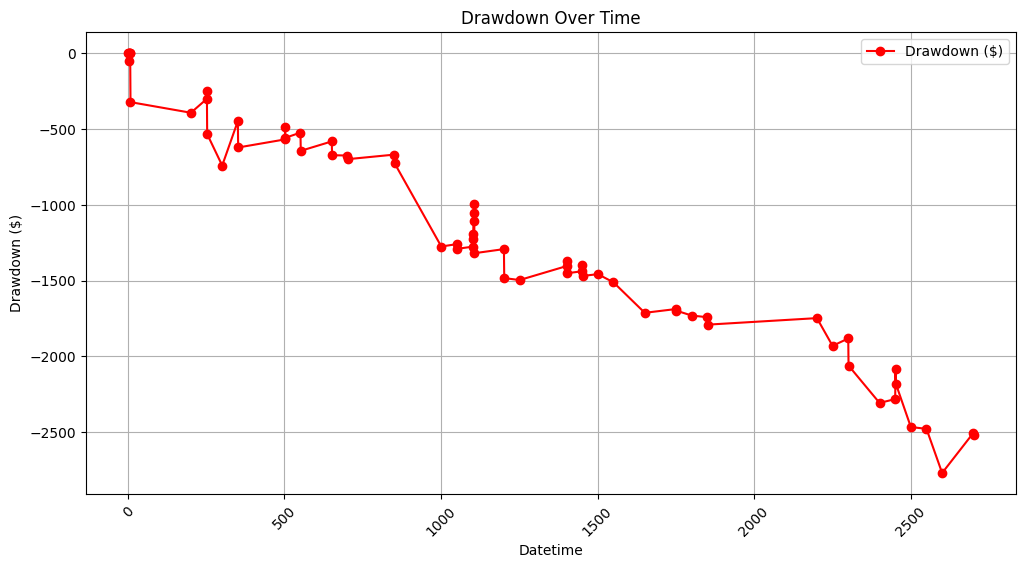

In [54]:
# Plotting the Drawdown Over Time
plt.figure(figsize=(12, 6))
plt.plot(trades_df.index, trades_df['drawdown'], marker='o', linestyle='-', color='red', label='Drawdown ($)')
plt.title('Drawdown Over Time')
plt.xlabel('Datetime')
plt.ylabel('Drawdown ($)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

/var/folders/b9/n8g7w60s6s50jwpyrnbrw1m80000gn/T/ipykernel_1253/2128061743.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/b9/n8g7w60s6s50jwpyrnbrw1m80000gn/T/ipykernel_1253/2128061743.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



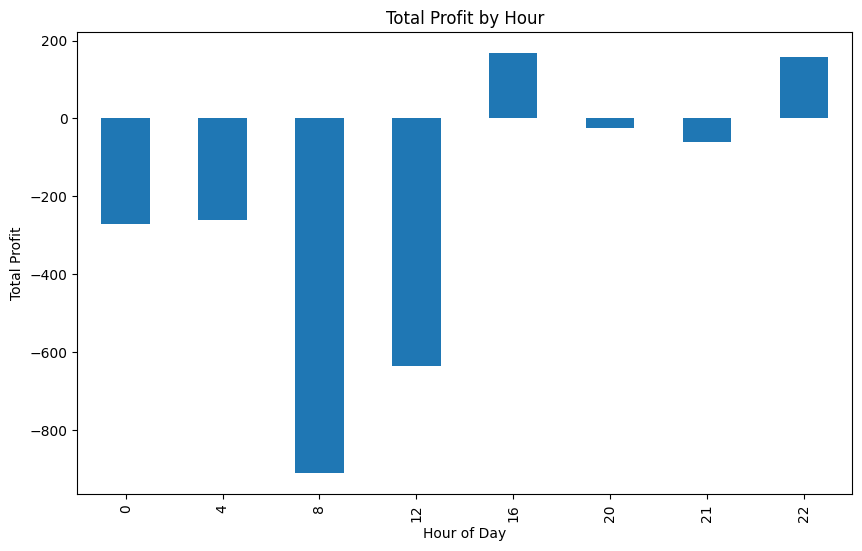

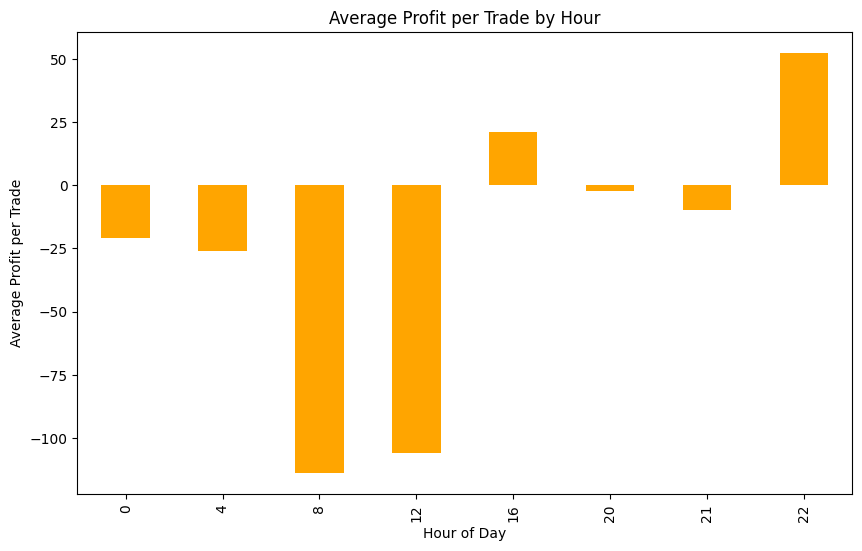

In [55]:
# Ensure the 'date' column is a datetime type and set it as the index

# Convert 'date' column to timezone-aware datetime values
trades_df['Datetime'] = pd.to_datetime(trades_df['date'], utc=True)
trades_df.set_index('Datetime', inplace=True)

# Extract the hour from the index and store it in a new column
trades_df['hour'] = trades_df.index.hour

# Group by hour and calculate the total profit and average profit per trade for each hour
hourly_profit = trades_df.groupby('hour')['profit'].agg(['sum', 'mean', 'count']).rename(columns={'sum': 'total_profit', 'mean': 'avg_profit', 'count': 'num_trades'})

# Plot total profit by hour
hourly_profit['total_profit'].plot(kind='bar', figsize=(10, 6), title='Total Profit by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Profit')
plt.show()

# Plot average profit per trade by hour
hourly_profit['avg_profit'].plot(kind='bar', figsize=(10, 6), color='orange', title='Average Profit per Trade by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Profit per Trade')
plt.show()

# Balance graphics with compound interest

In [117]:
# Calculate the updated balance simulating compound interest.
initial_balance = 10000.0
balance_list = []
current_balance = initial_balance

pd.set_option('display.float_format', '{:.2f}'.format)

trades_df = pd.DataFrame(trades_df)

for profit in trades_df['profit']:
    # Increase profit proportionally to the growth in current balance.
    scaled_profit = profit * (current_balance / initial_balance)
    current_balance += scaled_profit
    balance_list.append(current_balance)

trades_df['balance'] = balance_list

# Ensure the 'date' column is a datetime type
trades_df['date'] = pd.to_datetime(trades_df['date'])

# Group by year and get the last balance of each year
yearly_balance = trades_df.groupby(trades_df['date'].dt.year)['balance'].last()

# Calculate the percentage change per year based on the initial balance of 10000
yearly_percentage_change = yearly_balance.pct_change().fillna(0) * 100
yearly_percentage_change.iloc[0] = ((yearly_balance.iloc[0] - 10000) / 10000) * 100

print(f"Yearly balance: {yearly_balance}")
print(f"Yearly percentage change: {yearly_percentage_change}")

trades_df['cum_max'] = trades_df['balance'].cummax()
trades_df['drawdown'] = trades_df['balance'] - trades_df['cum_max']
trades_df['drawdown_pct'] = (trades_df['drawdown'] / trades_df['cum_max']) * 100

# Profit Factor Calculation:
total_profit = trades_df.loc[trades_df['profit'] > 0, 'profit'].sum()
total_loss = abs(trades_df.loc[trades_df['profit'] < 0, 'profit'].sum())
profit_factor = total_profit / total_loss if total_loss != 0 else float('inf')

print("Total Profit: ${:.2f}".format(total_profit))
print("Total Loss: ${:.2f}".format(total_loss))
print("Profit Factor: {:.2f}".format(profit_factor))
print("Maximum Drawdown: ${:.2f}".format(abs(trades_df['drawdown'].min())))
print("Maximum Drawdown (%): {:.2f}%".format(abs(trades_df['drawdown_pct'].min())))

Yearly balance: date
2024   10753.30
2025    9897.51
Name: balance, dtype: float64
Yearly percentage change: date
2024    7.53
2025   -7.96
Name: balance, dtype: float64
Total Profit: $14775.00
Total Loss: $14446.00
Profit Factor: 1.02
Maximum Drawdown: $2870.41
Maximum Drawdown (%): 27.95%


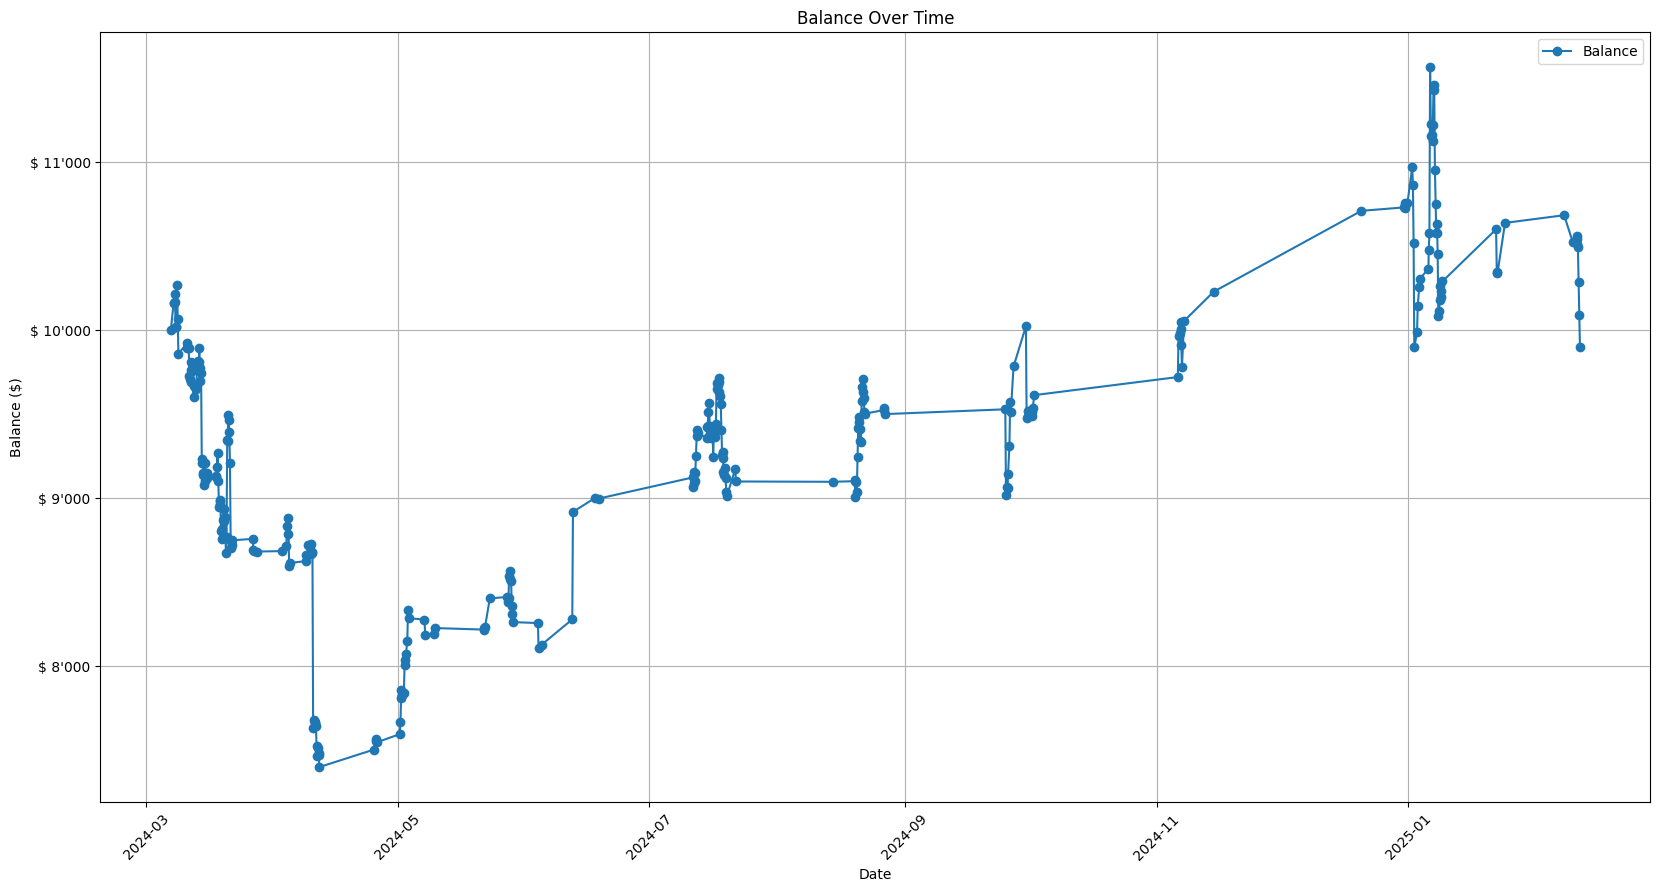

In [118]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def usd_formatter(x, pos):
    # Format the number with commas as thousand separators
    formatted = f"$ {x:,.0f}"
    # Replace commas with single quotes if desired
    formatted = formatted.replace(",", "'")
    return formatted

plt.figure(figsize=(20, 10))
plt.plot(trades_df['date'], trades_df['balance'], marker='o', linestyle='-', label='Balance')
plt.title('Balance Over Time')
plt.xlabel('Date')
plt.ylabel('Balance ($)')

# Set the y-axis formatter to our custom USD formatter
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))

plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()


In [119]:
import plotly.graph_objects as go
import plotly.express as px

# Create the figure
fig = go.Figure()

# Trace for Balance over time
fig.add_trace(go.Scatter(
    x=trades_df['date'],
    y=trades_df['balance'],
    mode='lines+markers',
    name='Balance',
    line=dict(color='green')
))

# Trace for Cumulative Maximum Balance
fig.add_trace(go.Scatter(
    x=trades_df['date'],
    y=trades_df['cum_max'],
    mode='lines',
    name='Cumulative Max Balance',
    line=dict(color='blue', dash='dash')
))

# Update layout to add a secondary y-axis and other styling
fig.update_layout(
    title='Balance, Cumulative Max Over Time',
    xaxis=dict(
        title='Date',
        rangeslider=dict(visible=True),
        type='date'
    ),
    yaxis=dict(
        title='Balance ($)',
        showgrid=True,
        zeroline=True
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
    margin=dict(l=50, r=50, t=80, b=50),
    template='plotly_white'
)

# Show the interactive plot
fig.show()


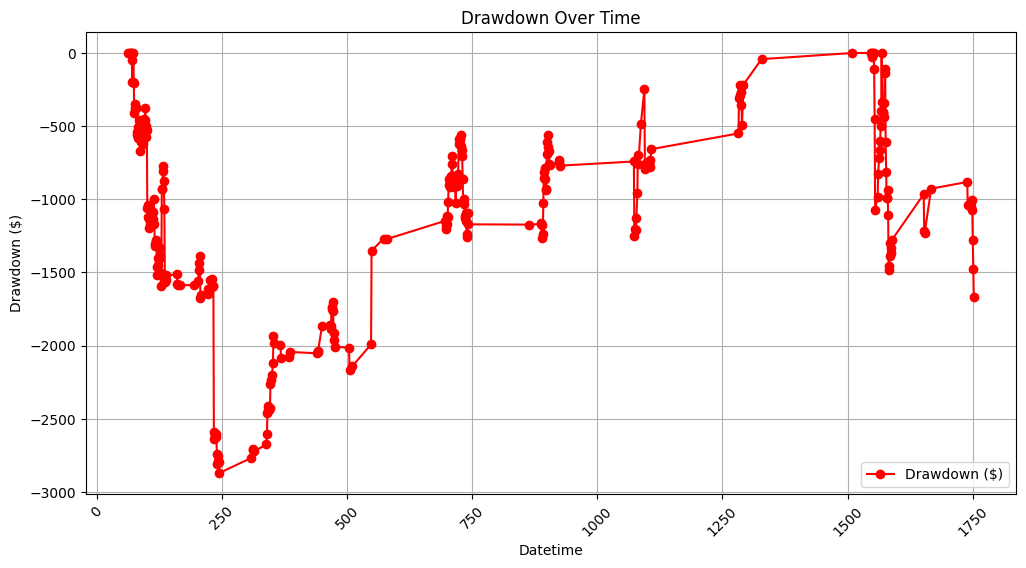

In [120]:
# Plotting the Drawdown Over Time
plt.figure(figsize=(12, 6))
plt.plot(trades_df.index, trades_df['drawdown'], marker='o', linestyle='-', color='red', label='Drawdown ($)')
plt.title('Drawdown Over Time')
plt.xlabel('Datetime')
plt.ylabel('Drawdown ($)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

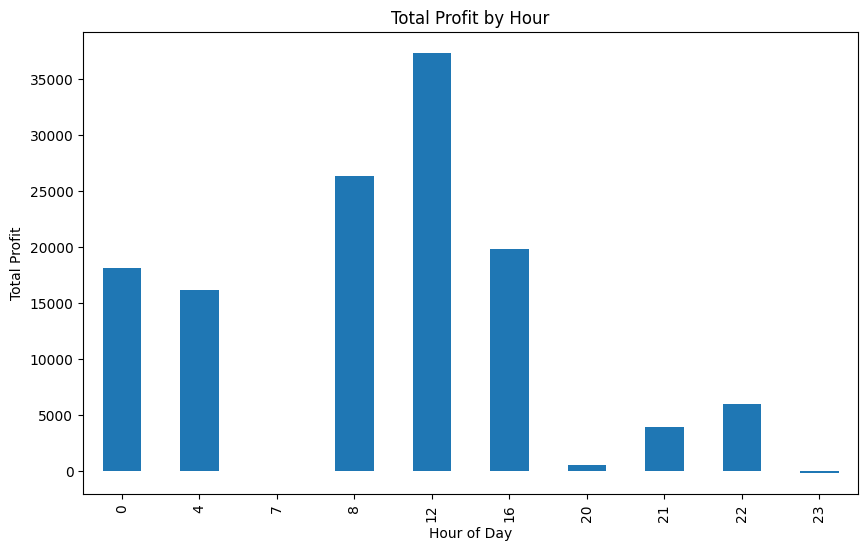

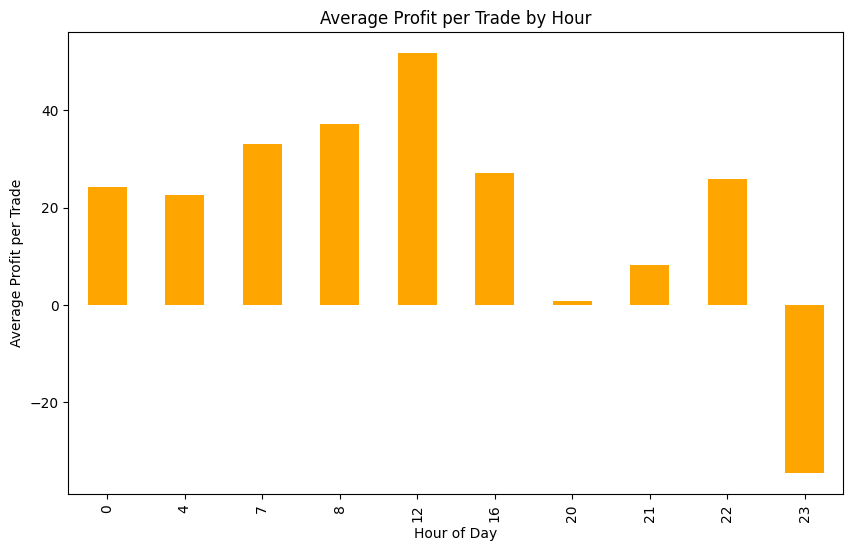

In [84]:
# Ensure the 'date' column is a datetime type and set it as the index

# Convert 'date' column to timezone-aware datetime values
trades_df['Datetime'] = pd.to_datetime(trades_df['date'], utc=True)
trades_df.set_index('Datetime', inplace=True)

# Extract the hour from the index and store it in a new column
trades_df['hour'] = trades_df.index.hour

# Group by hour and calculate the total profit and average profit per trade for each hour
hourly_profit = trades_df.groupby('hour')['profit'].agg(['sum', 'mean', 'count']).rename(columns={'sum': 'total_profit', 'mean': 'avg_profit', 'count': 'num_trades'})

# Plot total profit by hour
hourly_profit['total_profit'].plot(kind='bar', figsize=(10, 6), title='Total Profit by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Profit')
plt.show()

# Plot average profit per trade by hour
hourly_profit['avg_profit'].plot(kind='bar', figsize=(10, 6), color='orange', title='Average Profit per Trade by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Profit per Trade')
plt.show()